# CUSTOMER CHURN PREDICTION USING ANN

In this tutorial you will solve classification problem where in we have a dataset in which there are details of a bank's customers and the target variable is a binary variable reflecting the fact whether the customer left the bank (closed his account) or he continues to be a customer.

## Importing Libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import tensorflow 
from tensorflow.keras import Sequential
from tensorflow.keras import  callbacks
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error as mae
import seaborn as sns
%matplotlib inline

# for Interactive Shells
from IPython.display import display

#removing warnings
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

In [2]:
print(tensorflow.__version__)

2.15.0


## Import Dataset

In [3]:
# Importing the dataset
df = pd.read_csv('Churn_Modelling.csv',index_col='RowNumber')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1.1+ MB


In [5]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,,,,,,,,,,,,,
1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
# some columns are totally unproductive so let's remove them
df.drop(['CustomerId','Surname'],axis=1,inplace=True)

In [8]:
# some columns have text data so let's one hot encode them
#  for more on one hot encoding click this link below

df = pd.get_dummies(prefix='Geo',data=df,columns=['Geography'])

In [9]:
df.shape

(10000, 13)

In [10]:
df = df.replace(to_replace={'Gender': {'Female': 1,'Male':0}})

In [11]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geo_France,Geo_Germany,Geo_Spain
RowNumber,,,,,,,,,,,,,
1,619,1,42,2,0.00,1,1,1,101348.88,1,True,False,False
2,608,1,41,1,83807.86,1,0,1,112542.58,0,False,False,True
3,502,1,42,8,159660.80,3,1,0,113931.57,1,True,False,False
4,699,1,39,1,0.00,2,0,0,93826.63,0,True,False,False
5,850,1,43,2,125510.82,1,1,1,79084.10,0,False,False,True


In [12]:
df.shape

(10000, 13)

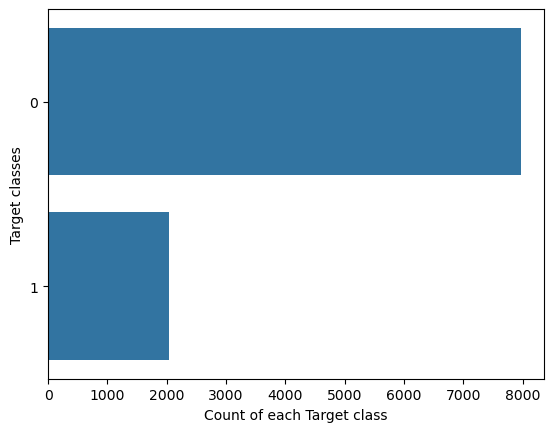

In [13]:
sns.countplot(y=df.Exited ,data=df)
plt.xlabel("Count of each Target class")
plt.ylabel("Target classes")
plt.show()

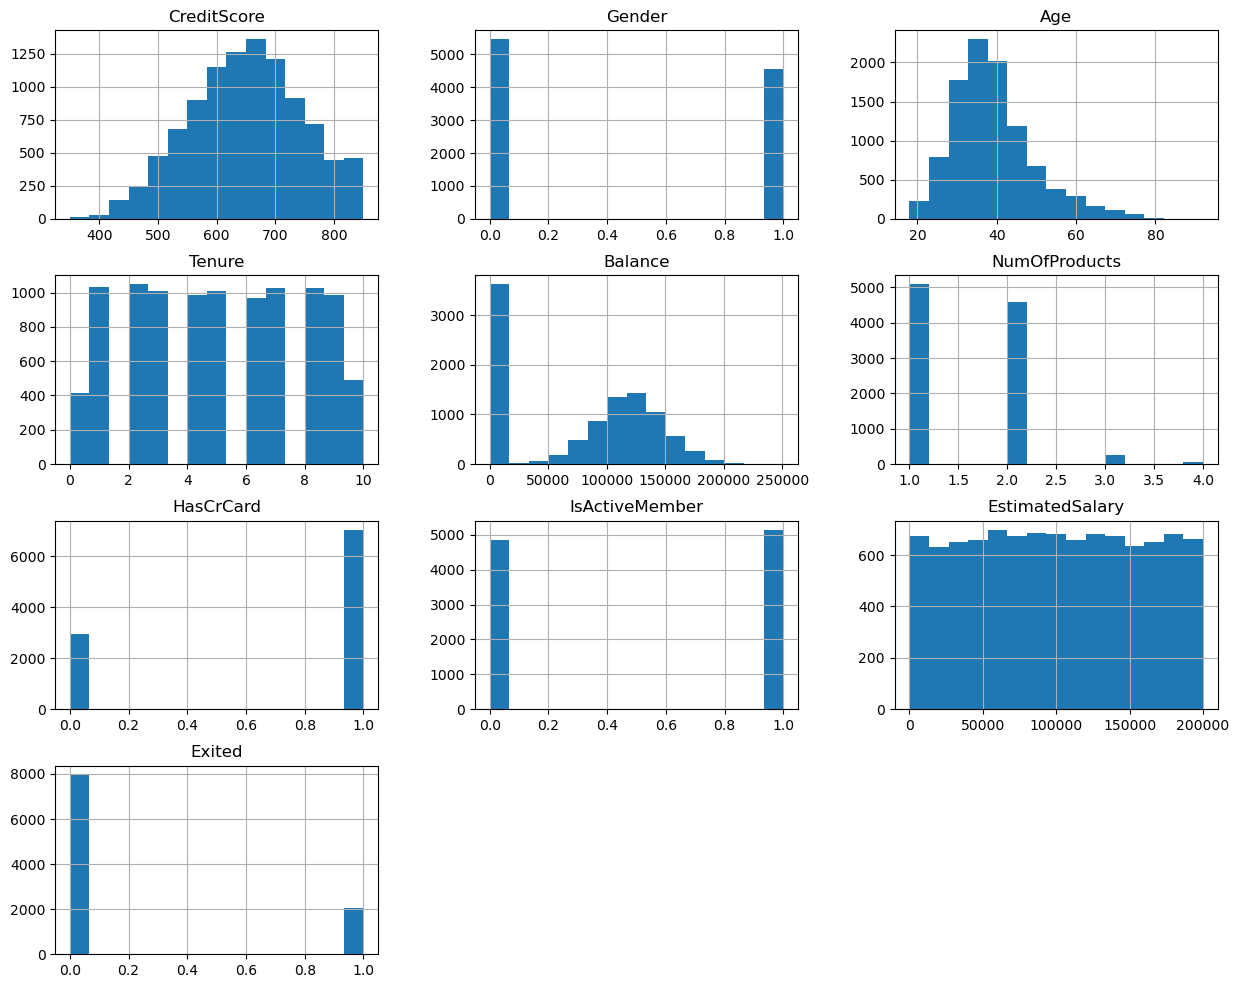

In [14]:
df.hist(figsize=(15,12),bins = 15)
plt.title("Features Distribution")
plt.show()

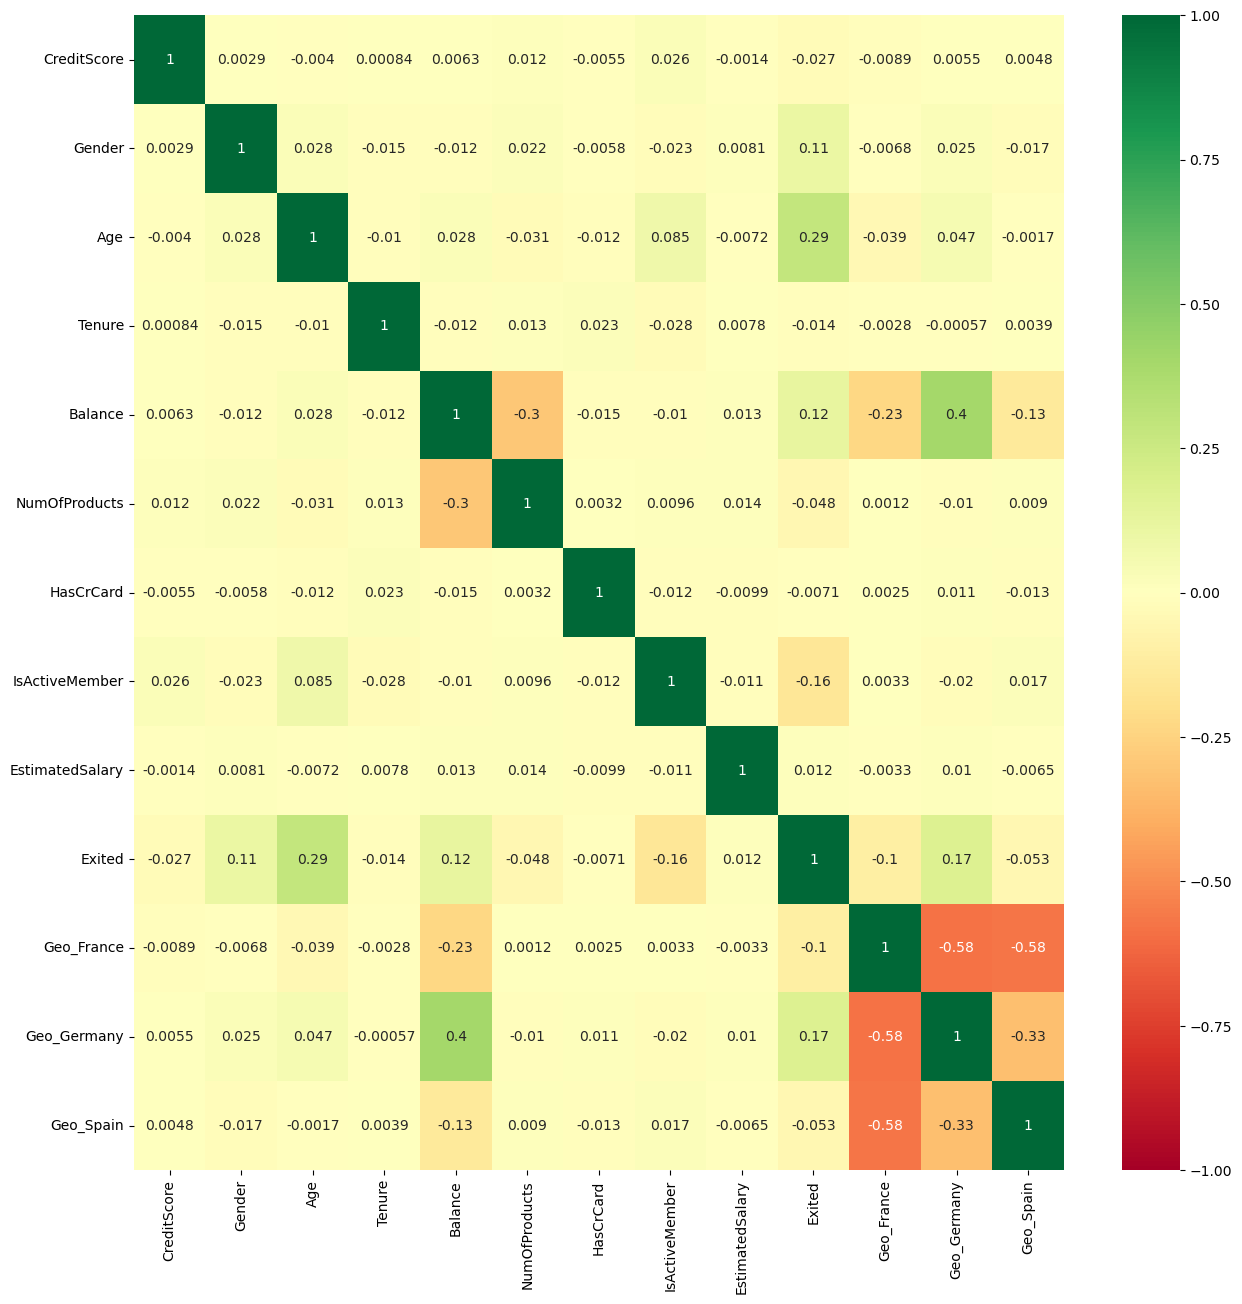

In [15]:
plt.figure(figsize=(15,15))
p=sns.heatmap(df.corr(), annot=True,cmap='RdYlGn',center=0, vmax=1.0, vmin=-1.0) 

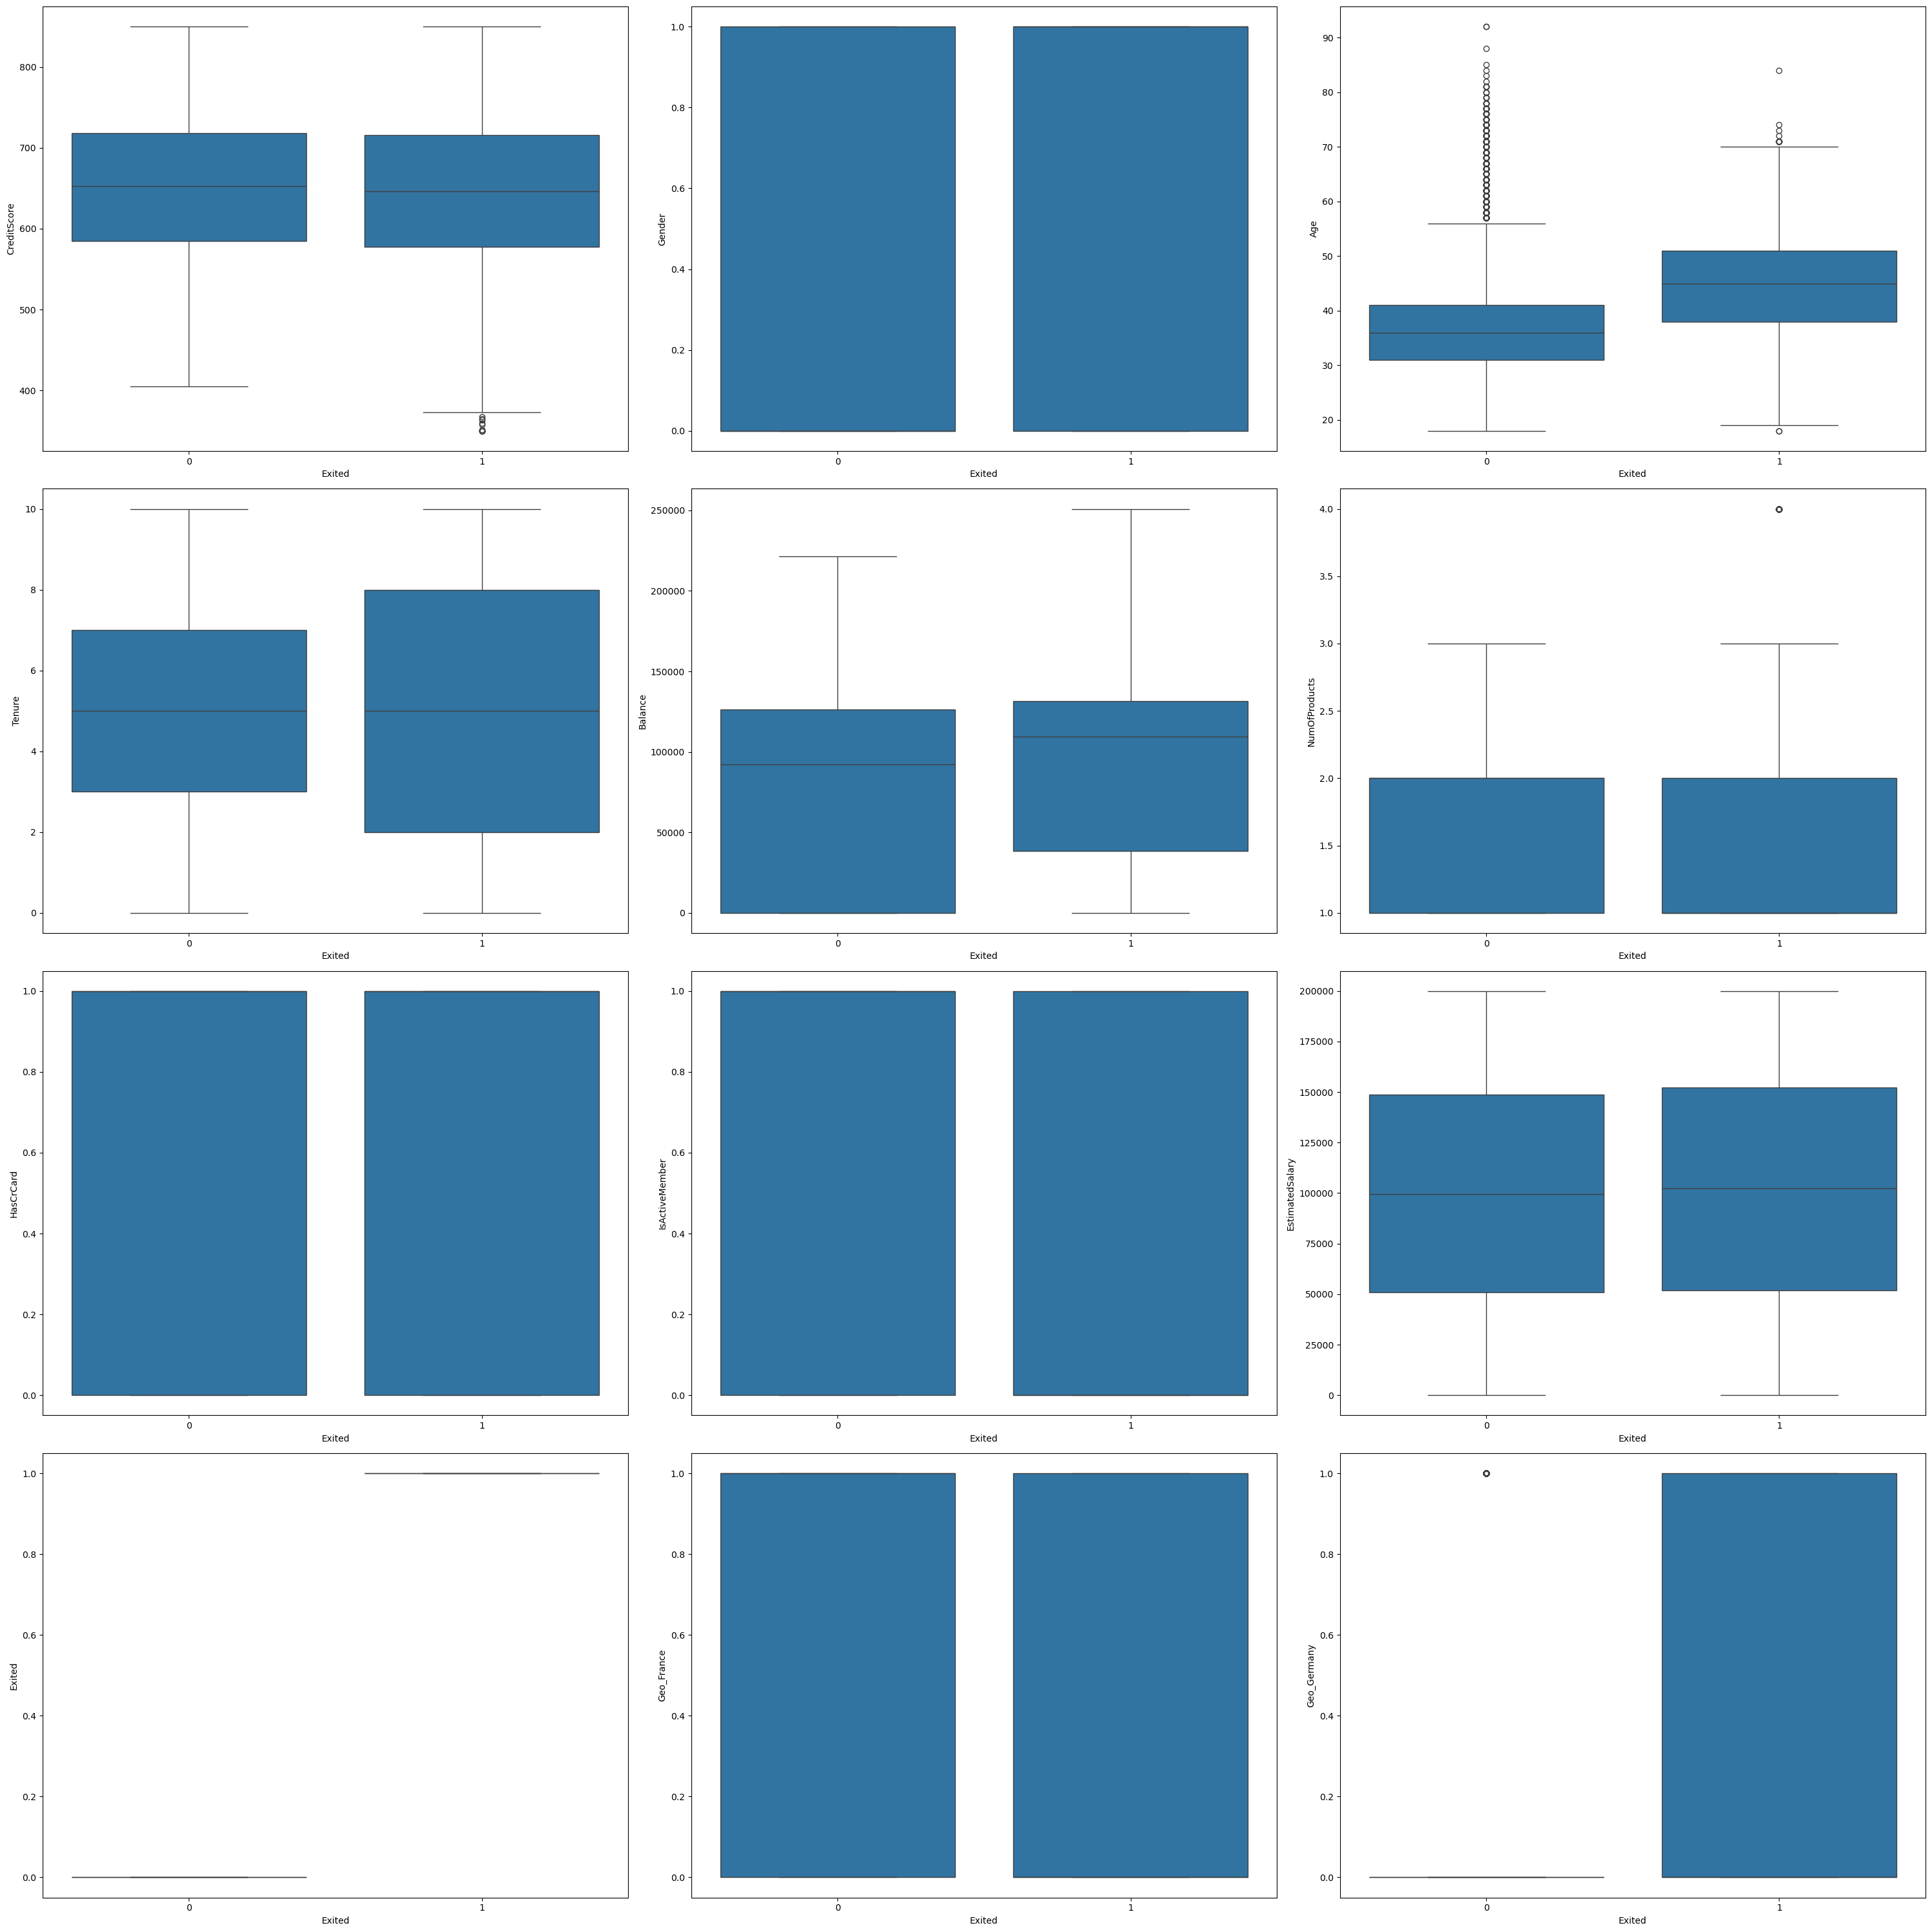

In [16]:
fig,ax = plt.subplots(nrows = 4, ncols=3, figsize=(30,30))
row = 0
col = 0
for i in range(len(df.columns) -1):
    if col > 2:
        row += 1
        col = 0
    axes = ax[row,col]
    sns.boxplot(x = df['Exited'], y = df[df.columns[i]],ax = axes)
    col += 1
plt.tight_layout()
# plt.title("Individual Features by Class")
plt.show()

In [17]:
y = df.Exited
X = df.drop(['Exited'],axis=1)

In [18]:
X.head(10)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geo_France,Geo_Germany,Geo_Spain
RowNumber,,,,,,,,,,,,
1,619,1,42,2,0.00,1,1,1,101348.88,True,False,False
2,608,1,41,1,83807.86,1,0,1,112542.58,False,False,True
3,502,1,42,8,159660.80,3,1,0,113931.57,True,False,False
4,699,1,39,1,0.00,2,0,0,93826.63,True,False,False
5,850,1,43,2,125510.82,1,1,1,79084.10,False,False,True
6,645,0,44,8,113755.78,2,1,0,149756.71,False,False,True
7,822,0,50,7,0.00,2,1,1,10062.80,True,False,False
8,376,1,29,4,115046.74,4,1,0,119346.88,False,True,False
9,501,0,44,4,142051.07,2,0,1,74940.50,True,False,False


In [19]:
# Splitting the dataset into the Training set and Test set

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 0)


In [20]:
# Feature Scaling because yes we don't want one independent variable dominating the other and it makes computations easy
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Model Building 

In [29]:
# sequential model to initialise our ann and dense module to build the layers
model = Sequential()

# Adding the input layer and the first hidden layer
model.add(Dense(units = 100, 
                kernel_initializer = 'uniform', 
                activation = 'relu',
                input_dim = 12))

# Adding the second hidden layer
model.add(Dense(units = 150, 
                kernel_initializer = 'uniform',
                activation = 'relu'))

# Adding the second hidden layer
model.add(Dense(units = 200, 
                kernel_initializer = 'uniform', 
                activation = 'relu'))

# Adding the second hidden layer
model.add(Dense(units = 400, 
                kernel_initializer = 'uniform', 
                activation = 'relu'))


# Adding the output layer
model.add(Dense(units = 1,
                kernel_initializer = 'uniform', 
                activation = 'sigmoid'))

In [30]:
# Compiling the ANN | means applying SGD on the whole ANN
model.compile(optimizer = 'adam', 
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

In [31]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_19 (Dense)            (None, 100)               1300      
                                                                 
 dense_20 (Dense)            (None, 150)               15150     
                                                                 
 dense_21 (Dense)            (None, 200)               30200     
                                                                 
 dense_22 (Dense)            (None, 400)               80400     
                                                                 
 dense_23 (Dense)            (None, 1)                 401       
                                                                 
Total params: 127451 (497.86 KB)
Trainable params: 127451 (497.86 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [32]:
# Fitting the ANN to the Training set
EPOCHS = 60
BATCH_SIZE  = 64


# train model
H = model.fit(X_train, 
              y_train, 
              batch_size = BATCH_SIZE, 
              epochs = EPOCHS,
              validation_split=0.2,
              verbose = 1)

Epoch 1/60
84/84 [==============================] - 5s 18ms/step - loss: 0.4787 - accuracy: 0.7957 - val_loss: 0.4250 - val_accuracy: 0.8000
Epoch 2/60
84/84 [==============================] - 1s 10ms/step - loss: 0.4182 - accuracy: 0.8106 - val_loss: 0.3962 - val_accuracy: 0.8381
Epoch 3/60
84/84 [==============================] - 1s 10ms/step - loss: 0.3734 - accuracy: 0.8485 - val_loss: 0.3532 - val_accuracy: 0.8537
Epoch 4/60
84/84 [==============================] - 1s 10ms/step - loss: 0.3517 - accuracy: 0.8537 - val_loss: 0.3481 - val_accuracy: 0.8634
Epoch 5/60
84/84 [==============================] - 1s 11ms/step - loss: 0.3439 - accuracy: 0.8580 - val_loss: 0.3456 - val_accuracy: 0.8619
Epoch 6/60
84/84 [==============================] - 1s 10ms/step - loss: 0.3431 - accuracy: 0.8595 - val_loss: 0.3444 - val_accuracy: 0.8590
Epoch 7/60
84/84 [==============================] - 1s 10ms/step - loss: 0.3378 - accuracy: 0.8616 - val_loss: 0.3489 - val_accuracy: 0.8567
Epoch 8/60
84

Epoch 59/60
84/84 [==============================] - 1s 10ms/step - loss: 0.0854 - accuracy: 0.9636 - val_loss: 0.9933 - val_accuracy: 0.8343
Epoch 60/60
84/84 [==============================] - 1s 11ms/step - loss: 0.0849 - accuracy: 0.9631 - val_loss: 1.0141 - val_accuracy: 0.8224


## Evaluation 

In [34]:
H.history

{'loss': [0.4787400960922241,
  0.418185293674469,
  0.3733985424041748,
  0.35174086689949036,
  0.3439261317253113,
  0.3431074619293213,
  0.3378467261791229,
  0.33722466230392456,
  0.3282569348812103,
  0.32618391513824463,
  0.323026567697525,
  0.3178510069847107,
  0.3158608376979828,
  0.31258606910705566,
  0.3095245361328125,
  0.30458635091781616,
  0.301676869392395,
  0.2963690161705017,
  0.2970668375492096,
  0.2891751229763031,
  0.28669223189353943,
  0.2830529808998108,
  0.2805171310901642,
  0.27043595910072327,
  0.2642871141433716,
  0.2634000778198242,
  0.2595299482345581,
  0.2540692985057831,
  0.24760308861732483,
  0.2513422667980194,
  0.23451818525791168,
  0.22679421305656433,
  0.2273014336824417,
  0.2215432971715927,
  0.21419426798820496,
  0.21144823729991913,
  0.2034471035003662,
  0.1914854347705841,
  0.19872470200061798,
  0.18339599668979645,
  0.17839257419109344,
  0.17132526636123657,
  0.1683710217475891,
  0.15713267028331757,
  0.161962

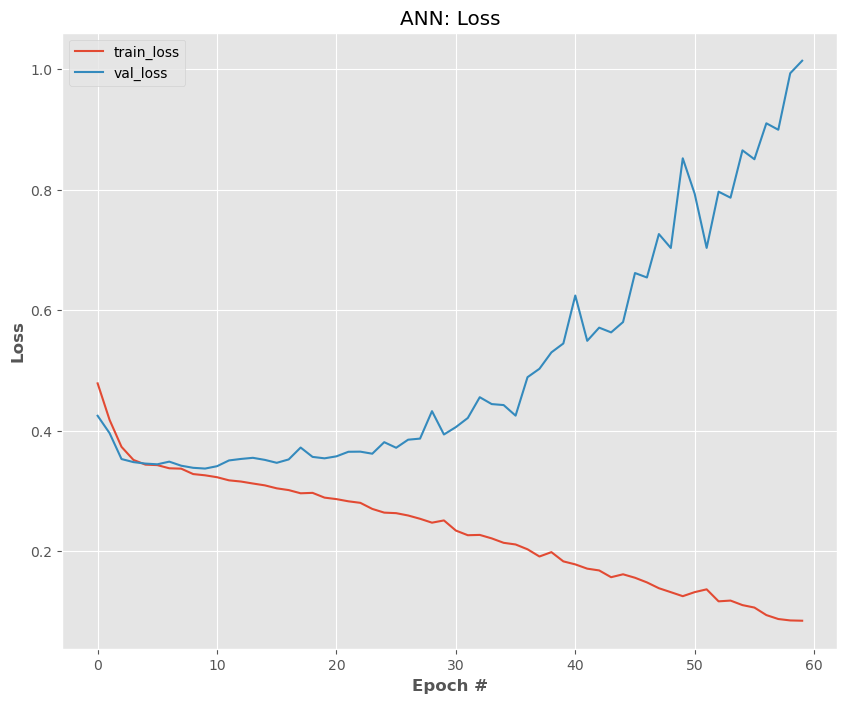

In [35]:
# plot the training and validation loss
N = np.arange(0, EPOCHS)
plt.style.use("ggplot")
plt.figure(figsize = [10,8])
plt.plot(N, H.history["loss"], label="train_loss")
plt.plot(N, H.history["val_loss"], label="val_loss")
plt.title("ANN: Loss")
plt.xlabel("Epoch #", weight="bold")
plt.ylabel("Loss", weight="bold")
plt.legend()
plt.show()

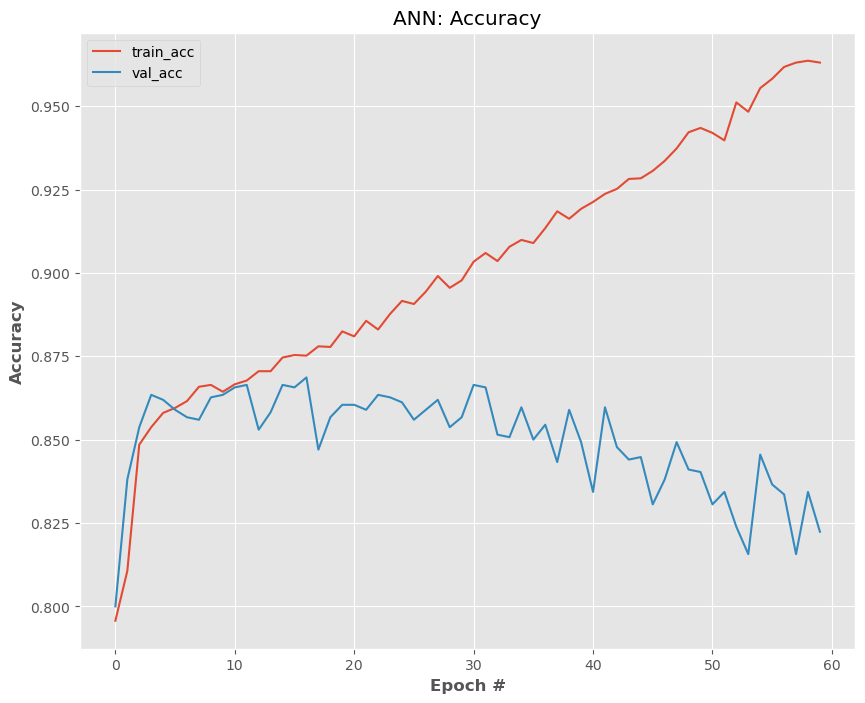

In [36]:
# plot the training and validation accuracy
N = np.arange(0, EPOCHS)
plt.style.use("ggplot")
plt.figure(figsize = [10,8])
plt.plot(N, H.history["accuracy"], label="train_acc")
plt.plot(N, H.history["val_accuracy"], label="val_acc")
plt.title("ANN: Accuracy")
plt.xlabel("Epoch #", weight="bold")
plt.ylabel("Accuracy", weight="bold")
plt.legend()
plt.show()

In [37]:
score, acc = model.evaluate(X_train, y_train,
                            batch_size=10)
print('Train score:', score)
print('Train accuracy:', acc)


670/670 [==============================] - 2s 2ms/step - loss: 0.2654 - accuracy: 0.9393
Train score: 0.26541414856910706
Train accuracy: 0.9392537474632263


In [38]:
# Part 3 - Making predictions and evaluating the model

# Predicting the Test set results
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

print('*'*20)
score, acc = model.evaluate(X_test, y_test,
                            batch_size=10)
print('Test score:', score)
print('Test accuracy:', acc)

104/104 [==============================] - 0s 3ms/step
********************
330/330 [==============================] - 1s 2ms/step - loss: 1.1120 - accuracy: 0.8045
Test score: 1.1120353937149048
Test accuracy: 0.8045454621315002


In [39]:

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

Text(0.5, 23.52222222222222, 'Predicted label')

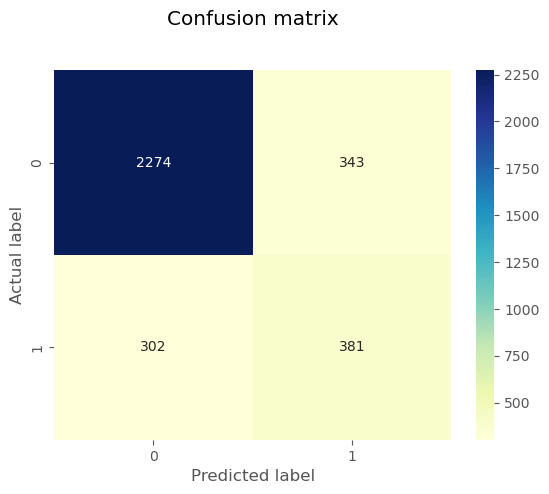

In [40]:
p = sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
plt.title('Confusion matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [41]:
#import classification_report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.88      0.87      0.88      2617
           1       0.53      0.56      0.54       683

    accuracy                           0.80      3300
   macro avg       0.70      0.71      0.71      3300
weighted avg       0.81      0.80      0.81      3300



104/104 [==============================] - 0s 3ms/step


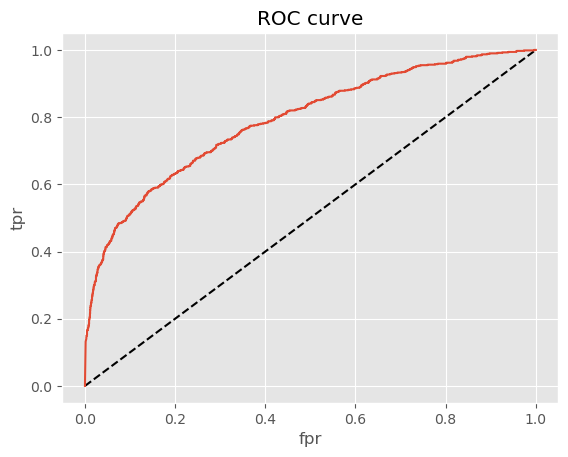

In [42]:
from sklearn.metrics import roc_curve
y_pred_proba = model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='ANN')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC curve')
plt.show()

In [43]:
#Area under ROC curve
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_pred_proba)

0.7908502856925463

<a id='12'></a>
# 12. Evaluation of Multiple Training Instances

In [48]:
# Part 4 - Evaluating, Improving and Tuning the ANN

# Evaluating the ANN
import keras
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import cross_val_score
from keras.models import Sequential
from keras.layers import Dense


def build_classifier():
    classifier = Sequential()
    classifier.add(Dense(units = 6, kernel_initializer = 'uniform', activation = 'relu', input_dim = 12))
    classifier.add(Dense(units = 6, kernel_initializer = 'uniform', activation = 'relu'))
    classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
    classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
    return classifier


classifier = KerasClassifier(build_fn = build_classifier, batch_size = 64, epochs = 50, verbose=1)

accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)

mean = accuracies.mean()
variance = accuracies.std()

ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Dev\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Dev\anaconda3\Lib\site-packages\keras\wrappers\scikit_learn.py", line 248, in fit
    return super().fit(x, y, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dev\anaconda3\Lib\site-packages\keras\wrappers\scikit_learn.py", line 167, in fit
    losses.is_categorical_crossentropy(self.model.loss)
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: module 'keras.losses' has no attribute 'is_categorical_crossentropy'


In [ ]:
print('Mean accuracy score of 10 different models using Kfold cross validation: {}'.format(mean))
print('Standard Deviation of accuracy score of 10 different models using Kfold cross validation: {}'.format(variance))

#### Deviation is very low so I'd say that it is unlikely to be an overfitted model. With different training sets it got the mean with all training results is still very close to the above model.

<a id='13'></a>
# 13. Improving ANN with Dropout layer

#### Dropout Regularization is used to reduce overfitting if needed.

#### p is the fraction of input units to drop. If suppose there are ten neurons from a layer and p is 0.1 then one of the neurons would be disabled and its output would not be sent to the further layer.
#### It is advisable to start with p 0.1 and move to higher values when in case the overfitting problem persists. Also going over 0.5 is not advisable generally because it may cause underfitting as most of the neurons are disabled.


In [49]:
# Improving the ANN
from tensorflow.keras.layers import Dropout
classifier = Sequential()

# Adding the input layer and the first hidden layer
classifier.add(Dense(units = 6, kernel_initializer = 'uniform', activation = 'relu', input_dim = 12))
classifier.add(Dropout(rate = 0.1))

# Adding the second hidden layer
classifier.add(Dense(units = 6, kernel_initializer = 'uniform', activation = 'relu'))
classifier.add(Dropout(rate = 0.1))

# Adding the output layer
classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))

# Compiling the ANN
classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

# Fitting the ANN to the Training set
classifier.fit(X_train, y_train, batch_size = 64, epochs = 50,verbose = 1)

Epoch 1/50
105/105 [==============================] - 2s 2ms/step - loss: 0.6678 - accuracy: 0.7954
Epoch 2/50
105/105 [==============================] - 0s 2ms/step - loss: 0.5461 - accuracy: 0.7979
Epoch 3/50
105/105 [==============================] - 0s 3ms/step - loss: 0.4550 - accuracy: 0.7979
Epoch 4/50
105/105 [==============================] - 0s 3ms/step - loss: 0.4358 - accuracy: 0.8018
Epoch 5/50
105/105 [==============================] - 0s 2ms/step - loss: 0.4280 - accuracy: 0.8142
Epoch 6/50
105/105 [==============================] - 0s 2ms/step - loss: 0.4177 - accuracy: 0.8128
Epoch 7/50
105/105 [==============================] - 0s 2ms/step - loss: 0.4163 - accuracy: 0.8193
Epoch 8/50
105/105 [==============================] - 0s 2ms/step - loss: 0.4143 - accuracy: 0.8221
Epoch 9/50
105/105 [==============================] - 0s 2ms/step - loss: 0.4120 - accuracy: 0.8175
Epoch 10/50
105/105 [==============================] - 0s 2ms/step - loss: 0.4108 - accuracy: 0.8187

In [50]:
# Part 3 - Making predictions and evaluating the model
score, acc = classifier.evaluate(X_train, y_train,
                            batch_size=10)
print('Train score:', score)
print('Train accuracy:', acc)
# Part 3 - Making predictions and evaluating the model

# Predicting the Test set results
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

print('*'*20)
score, acc = classifier.evaluate(X_test, y_test,
                            batch_size=10)
print('Test score:', score)
print('Test accuracy:', acc)

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

670/670 [==============================] - 2s 2ms/step - loss: 0.3706 - accuracy: 0.8346
Train score: 0.3705926537513733
Train accuracy: 0.8346268534660339
104/104 [==============================] - 0s 2ms/step
********************
330/330 [==============================] - 1s 2ms/step - loss: 0.3733 - accuracy: 0.8297
Test score: 0.3732866942882538
Test accuracy: 0.8296969532966614


Text(0.5, 23.52222222222222, 'Predicted label')

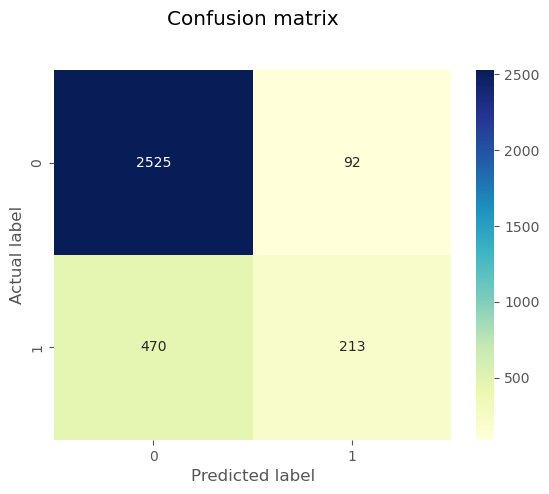

In [51]:
p = sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [52]:
#import classification_report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.96      0.90      2617
           1       0.70      0.31      0.43       683

    accuracy                           0.83      3300
   macro avg       0.77      0.64      0.67      3300
weighted avg       0.81      0.83      0.80      3300



104/104 [==============================] - 0s 2ms/step


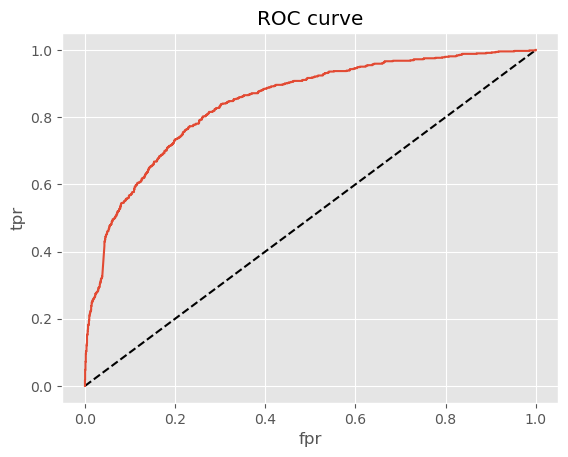

In [53]:
from sklearn.metrics import roc_curve
y_pred_proba = classifier.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='ANN')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC curve')
plt.show()

In [54]:
#Area under ROC curve
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_pred_proba)

0.8446675107180162


# Tuning the ANN

#### Let's test 2 values of the batch size and we're gonna try 25 and 32. So why 25 and 32? Well, that's based on my experience and that's also common practice to take powers of 2. Well, you can try other values of the batch size as well.

In [ ]:

# Tuning the ANN
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import GridSearchCV
from keras.models import Sequential
from keras.layers import Dense
def build_classifier(optimizer):
    classifier = Sequential()
    classifier.add(Dense(units = 6, kernel_initializer = 'uniform', activation = 'relu', input_dim = 12))
    classifier.add(Dense(units = 6, kernel_initializer = 'uniform', activation = 'relu'))
    classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
    classifier.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])
    return classifier
classifier = KerasClassifier(build_fn = build_classifier)
parameters = {'batch_size': [25, 32],
              'epochs': [100, 200],
              'optimizer': ['adam', 'rmsprop']}
grid_search = GridSearchCV(estimator = classifier,
                           param_grid = parameters,
                           scoring = 'accuracy',
                           cv = 10)
grid_search = grid_search.fit(X_train, y_train,verbose = 0)
best_parameters = grid_search.best_params_
best_accuracy = grid_search.best_score_

In [ ]:
print('Best Parameters after tuning: {}'.format(best_parameters))
print('Best Accuracy after tuning: {}'.format(best_accuracy))